# DiffusionPen - Handwritten Text Generation
Generate realistic handwritten text on PDF form templates using [DiffusionPen](https://github.com/koninik/DiffusionPen) (ECCV 2024).

**Workflow:**
1. Clone DiffusionPen repo and download pretrained models
2. Load PDF template from Google Drive (or local path)
3. Use multi-page coordinate picker to mark field positions and assign field types
4. Configure number of copies to generate (N)
5. Generate N filled copies â€” each set uses a different handwriting style, consistent within the set

In [2]:
# Cell 1: Setup and Dependencies
import os
import sys
import json
import subprocess
import platform
from pathlib import Path
from IPython.display import display, Image as IPImage
import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

# Install core dependencies
try:
    import fitz
except ImportError:
    subprocess.check_call(['pip', 'install', 'pymupdf', '-q'])
    import fitz

try:
    from PIL import Image, ImageDraw, ImageFont
except ImportError:
    subprocess.check_call(['pip', 'install', 'Pillow', '-q'])
    from PIL import Image, ImageDraw, ImageFont

import matplotlib.pyplot as plt
import numpy as np

# DiffusionPen dependencies
for pkg in ['torch', 'torchvision', 'diffusers', 'transformers', 'timm', 'tqdm', 'omegaconf']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call(['pip', 'install', pkg, '-q'])

import torch

print(f"Platform: {platform.system()}")
print(f"PyMuPDF: {fitz.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("\nAll dependencies loaded!")

Platform: Windows
PyMuPDF: ('1.26.7', '1.26.12', None)
PyTorch: 2.9.1+cpu
CUDA available: False

All dependencies loaded!


In [3]:
# Cell 2: Clone DiffusionPen and download models
DIFFPEN_DIR = Path("DiffusionPen")

# Clone repo if not present
if not DIFFPEN_DIR.exists():
    print("Cloning DiffusionPen repository...")
    subprocess.check_call(['git', 'clone', 'https://github.com/koninik/DiffusionPen.git'])
    print("Done.")
else:
    print(f"DiffusionPen already cloned at {DIFFPEN_DIR}")

# Download pretrained models from HuggingFace
try:
    from huggingface_hub import snapshot_download, hf_hub_download
except ImportError:
    subprocess.check_call(['pip', 'install', 'huggingface_hub', '-q'])
    from huggingface_hub import snapshot_download, hf_hub_download

HF_REPO = "konnik/DiffusionPen"

# Download style encoder
style_model_path = DIFFPEN_DIR / "style_models" / "iam_style_diffusionpen.pth"
if not style_model_path.exists():
    print("Downloading style encoder model...")
    (DIFFPEN_DIR / "style_models").mkdir(parents=True, exist_ok=True)
    hf_hub_download(
        repo_id=HF_REPO,
        filename="style_models/iam_style_diffusionpen.pth",
        local_dir=str(DIFFPEN_DIR),
    )
    print("Done.")
else:
    print(f"Style encoder already present")

# Download pretrained DiffusionPen checkpoint
ckpt_path = DIFFPEN_DIR / "diffusionpen_iam_model_path" / "models" / "ema_ckpt.pt"
if not ckpt_path.exists():
    print("Downloading DiffusionPen checkpoint (this may take a while)...")
    (DIFFPEN_DIR / "diffusionpen_iam_model_path" / "models").mkdir(parents=True, exist_ok=True)
    for fname in ["models/ema_ckpt.pt", "models/ckpt.pt", "models/optim.pt"]:
        try:
            hf_hub_download(
                repo_id=HF_REPO,
                filename=f"diffusionpen_iam_model_path/{fname}",
                local_dir=str(DIFFPEN_DIR),
            )
            print(f"  Downloaded {fname}")
        except Exception as e:
            print(f"  Warning: Could not download {fname}: {e}")
    print("Done.")
else:
    print(f"DiffusionPen checkpoint already present")

# Download preprocessed IAM data for style references
saved_data_path = DIFFPEN_DIR / "saved_iam_data"
if not saved_data_path.exists():
    print("Downloading preprocessed IAM data...")
    saved_data_path.mkdir(parents=True, exist_ok=True)
    # Download all .pt files in saved_iam_data
    try:
        snapshot_download(
            repo_id=HF_REPO,
            allow_patterns="saved_iam_data/*",
            local_dir=str(DIFFPEN_DIR),
        )
        print("Done.")
    except Exception as e:
        print(f"Warning: Could not download saved_iam_data: {e}")
        print("You may need to download manually from https://huggingface.co/konnik/DiffusionPen")
else:
    print(f"Preprocessed IAM data already present")

print("\nModel files:")
for p in [style_model_path, ckpt_path, saved_data_path]:
    status = 'OK' if p.exists() else 'MISSING'
    print(f"  [{status}] {p}")

DiffusionPen already cloned at DiffusionPen
Style encoder already present
DiffusionPen checkpoint already present
Preprocessed IAM data already present

Model files:
  [OK] DiffusionPen\style_models\iam_style_diffusionpen.pth
  [OK] DiffusionPen\diffusionpen_iam_model_path\models\ema_ckpt.pt
  [OK] DiffusionPen\saved_iam_data


In [ ]:
# Cell 3: Configuration
RENDER_SCALE = 2  # 2x resolution for PDF rendering

# â”€â”€ Template PDF path â”€â”€
# In Colab: upload your PDF to Google Drive and set the path below.
# Locally: use a Windows/Mac path.
if IN_COLAB:
    DRIVE_BASE = Path("/content/drive/MyDrive")
    # Put your template PDF in Google Drive and set the path:
    TEMPLATE_PDF = DRIVE_BASE / "Capstone" / "Documents" / "JMS-Prisoner-Registration-Form.pdf"
    # Output goes to Drive so it persists after session ends
    OUTPUT_FOLDER = DRIVE_BASE / "Capstone" / "diffusionpen_output"
    FIELD_CONFIGS_FOLDER = DRIVE_BASE / "Capstone" / "field_configs"
else:
    TEMPLATE_PDF = Path(r"C:\Users\leolw\OneDrive\Documents\MSAIB\Capstone\Documents\JMS-Prisoner-Registration-Form.pdf")
    OUTPUT_FOLDER = Path("diffusionpen_output")
    FIELD_CONFIGS_FOLDER = Path("field_configs")

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
FIELD_CONFIGS_FOLDER.mkdir(parents=True, exist_ok=True)

# â”€â”€ Number of form copies to generate â”€â”€
NUM_COPIES = 10  # Change this to generate more or fewer copies

# â”€â”€ Device for DiffusionPen â”€â”€
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: DiffusionPen is very slow on CPU. GPU is strongly recommended.")
    print("In Colab: Runtime â†’ Change runtime type â†’ GPU")

print(f"\nTemplate: {TEMPLATE_PDF}")
print(f"  Exists: {TEMPLATE_PDF.exists()}")
print(f"Output:   {OUTPUT_FOLDER}/")
print(f"Copies:   {NUM_COPIES}")

In [5]:
# Cell 4: Helper functions

def pdf_to_images(pdf_path, scale=RENDER_SCALE):
    """Convert all pages of a PDF to PIL Images."""
    pdf_doc = fitz.open(str(pdf_path))
    images = []
    for page_num in range(len(pdf_doc)):
        page = pdf_doc[page_num]
        mat = fitz.Matrix(scale, scale)
        pix = page.get_pixmap(matrix=mat)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(img)
    pdf_doc.close()
    return images

def load_field_config(config_path):
    with open(config_path, 'r') as f:
        return json.load(f)

def save_field_config(config, config_path):
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Saved config to {config_path}")

print("Helper functions loaded!")

Helper functions loaded!


Template has 2 page(s)
  Page 1: 1224x1584 px
  Page 2: 1224x1584 px


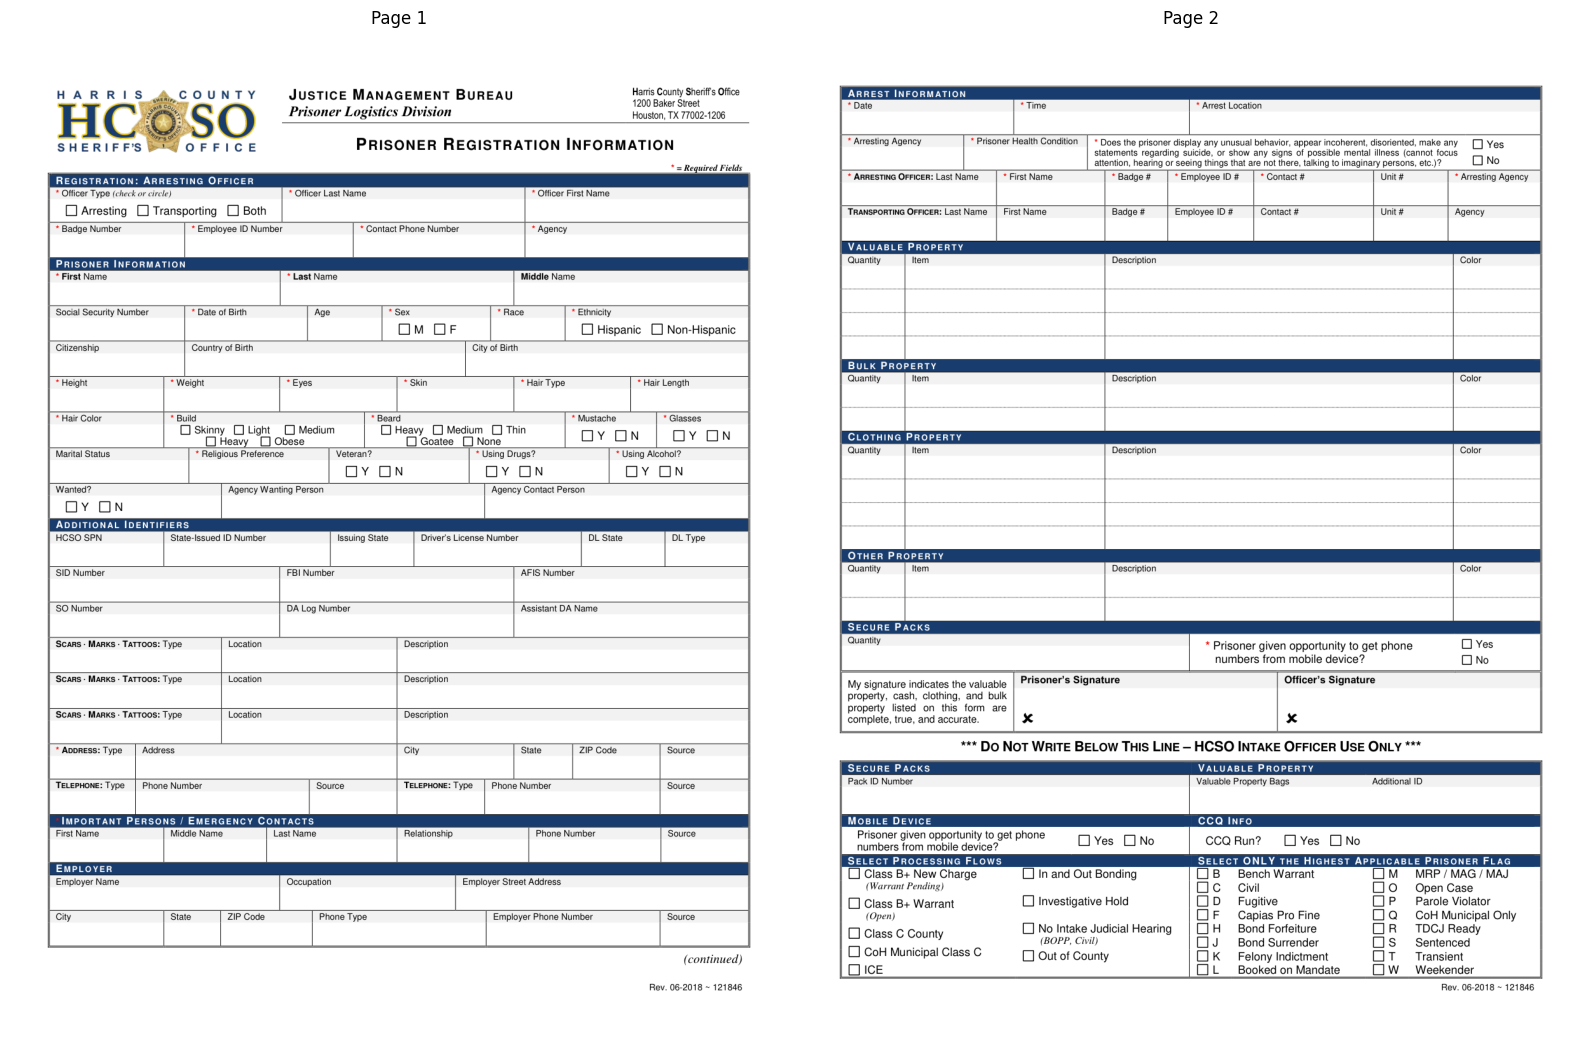

In [6]:
# Cell 5: Load and display the template
assert TEMPLATE_PDF.exists(), f"Template not found: {TEMPLATE_PDF}"

template_pages = pdf_to_images(TEMPLATE_PDF)
print(f"Template has {len(template_pages)} page(s)")
for i, img in enumerate(template_pages):
    print(f"  Page {i+1}: {img.size[0]}x{img.size[1]} px")

# Display page 1
fig, axes = plt.subplots(1, len(template_pages), figsize=(8 * len(template_pages), 12))
if len(template_pages) == 1:
    axes = [axes]
for i, (ax, img) in enumerate(zip(axes, template_pages)):
    ax.imshow(img)
    ax.set_title(f"Page {i+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Display all template pages
# Shows all pages for reference before using the coordinate picker.

print(f"Template has {len(template_pages)} page(s)")
fig, axes = plt.subplots(1, len(template_pages), figsize=(8 * len(template_pages), 11))
if len(template_pages) == 1:
    axes = [axes]
for i, page in enumerate(template_pages):
    axes[i].imshow(page)
    axes[i].set_title(f"Page {i + 1} ({page.size[0]}x{page.size[1]} px)")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Multi-Page Coordinate Picker with Field Types
# Click on any page to mark field positions.
# For each click, select the field type from the dropdown.
# All pages are shown â€” click across pages freely.
# Press "Sync to Python" to finalize (or it auto-syncs).

import base64, io, json
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# â”€â”€ Available field types â”€â”€
FIELD_TYPES = [
    "first_name", "last_name", "full_name",
    "numerical_short", "numerical_long",
    "phone_number", "zip_code", "social_security_number",
    "date", "dob",
    "short_sentence", "long_sentence",
    "check_mark", "x_mark",
    "height", "weight",
    "address", "city", "state", "country",
    "county", "cause_number", "charge",
    "color", "length",
    "company", "occupation",
    "badge_number", "employee_id",
    "signature",
    "other",
]

# Accumulated fields across ALL pages: [{page, x, y, field_type, label}, ...]
all_fields = []

# â”€â”€ Widgets â”€â”€
field_type_dropdown = widgets.Dropdown(
    options=FIELD_TYPES,
    value="first_name",
    description="Field type:",
    layout=widgets.Layout(width="300px"),
)
field_label_input = widgets.Text(
    value="",
    placeholder="Optional custom label (e.g. officer_name)",
    description="Label:",
    layout=widgets.Layout(width="400px"),
)
status_output = widgets.Output()
picker_output = widgets.Output()
json_output = widgets.Textarea(
    value="[]",
    description="Fields JSON:",
    layout=widgets.Layout(width="100%", height="100px"),
    disabled=True,
)

def update_json_display():
    json_output.value = json.dumps(all_fields, indent=2)

def sync_to_python(b=None):
    """Sync fields from JSON display back to Python (for manual JSON edits)."""
    global all_fields
    try:
        all_fields = json.loads(json_output.value)
    except:
        pass
    with status_output:
        clear_output(wait=True)
        print(f"Synced {len(all_fields)} field(s):")
        for i, f in enumerate(all_fields):
            label = f.get("label", f["field_type"])
            print(f"  {i+1}. Page {f['page']+1} | ({f['x']}, {f['y']}) | {f['field_type']} | {label}")

def on_clear(b):
    global all_fields
    all_fields = []
    update_json_display()
    render_all_pages()
    sync_to_python()

def undo_last(b):
    global all_fields
    if all_fields:
        removed = all_fields.pop()
        update_json_display()
        render_all_pages()
        with status_output:
            clear_output(wait=True)
            label = removed.get("label", removed["field_type"])
            print(f"Removed: Page {removed['page']+1} | {label}")
            print(f"{len(all_fields)} field(s) remaining")

sync_btn = widgets.Button(description="Sync to Python", button_style="primary")
clear_btn = widgets.Button(description="Clear All", button_style="warning")
undo_btn = widgets.Button(description="Undo Last", button_style="info")
sync_btn.on_click(sync_to_python)
clear_btn.on_click(on_clear)
undo_btn.on_click(undo_last)

def render_all_pages():
    """Render all pages with field markers, using Colab-compatible click handling."""
    page_htmls = []

    for page_idx, page_img in enumerate(template_pages):
        img_w, img_h = page_img.size
        max_w = 750
        sc = min(1.0, max_w / img_w)
        dw, dh = int(img_w * sc), int(img_h * sc)

        buf = io.BytesIO()
        page_img.resize((dw, dh)).save(buf, format="PNG")
        b64 = base64.b64encode(buf.getvalue()).decode()

        pid = f"page_{page_idx}"

        # Draw existing markers for this page
        dots = ""
        for i, f in enumerate(all_fields):
            if f["page"] != page_idx:
                continue
            dx, dy = int(f["x"] * sc), int(f["y"] * sc)
            label = f.get("label", f["field_type"])
            short = label[:12] if len(label) > 12 else label
            dots += f'<circle cx="{dx}" cy="{dy}" r="7" fill="red" stroke="darkred" stroke-width="2"/>'
            dots += f'<text x="{dx+12}" y="{dy+4}" fill="red" font-size="11" font-weight="bold">{i+1}. {short}</text>'

        page_htmls.append(f'''
        <div style="margin-bottom:10px;">
            <h3 style="margin:4px 0;">Page {page_idx + 1}</h3>
            <div id="{pid}_c" style="position:relative;display:inline-block;border:2px solid #333;cursor:crosshair;" data-page="{page_idx}" data-scale="{sc}">
                <img src="data:image/png;base64,{b64}" style="display:block;"/>
                <svg width="{dw}" height="{dh}" style="position:absolute;top:0;left:0;pointer-events:none;">{dots}</svg>
            </div>
            <div id="{pid}_info" style="font-family:monospace;color:#666;font-size:12px;">Click to mark fields</div>
        </div>
        ''')

    # JavaScript that handles clicks on ANY page and calls Python via Colab kernel
    # For non-Colab (Jupyter), falls back to updating a hidden input
    click_js = '''
    <script>
    (function() {
        document.querySelectorAll('[id$="_c"]').forEach(function(container) {
            container.addEventListener('click', function(e) {
                const page = parseInt(this.dataset.page);
                const sc = parseFloat(this.dataset.scale);
                const img = this.querySelector('img');
                const rect = img.getBoundingClientRect();
                const x = Math.round((e.clientX - rect.left) / sc);
                const y = Math.round((e.clientY - rect.top) / sc);

                // Try Colab kernel callback first, then fallback
                if (window.google && google.colab && google.colab.kernel) {
                    google.colab.kernel.invokeFunction('on_click', [page, x, y], {});
                } else {
                    // Jupyter fallback: write to hidden input and trigger change
                    const inp = document.getElementById('_click_data');
                    if (inp) {
                        inp.value = JSON.stringify({page: page, x: x, y: y});
                        inp.dispatchEvent(new Event('change'));
                    }
                }

                // Visual feedback
                const ns = 'http://www.w3.org/2000/svg';
                const svg = this.querySelector('svg');
                const ci = document.createElementNS(ns, 'circle');
                ci.setAttribute('cx', e.clientX - rect.left);
                ci.setAttribute('cy', e.clientY - rect.top);
                ci.setAttribute('r', '7');
                ci.setAttribute('fill', 'lime');
                ci.setAttribute('stroke', 'green');
                ci.setAttribute('stroke-width', '2');
                svg.appendChild(ci);

                const info = document.getElementById('page_' + page + '_info');
                if (info) info.textContent = 'Clicked: (' + x + ', ' + y + ') on page ' + (page + 1);
            });
        });
    })();
    </script>
    <input type="hidden" id="_click_data" value=""/>
    '''

    with picker_output:
        clear_output(wait=True)
        display(HTML("".join(page_htmls) + click_js))

# â”€â”€ Colab callback for click events â”€â”€
if IN_COLAB:
    from google.colab import output as colab_output

    def _on_click(page, x, y):
        field_type = field_type_dropdown.value
        label = field_label_input.value.strip() or field_type
        all_fields.append({
            "page": page, "x": x, "y": y,
            "field_type": field_type, "label": label,
        })
        field_label_input.value = ""  # Reset label for next field
        update_json_display()
        with status_output:
            clear_output(wait=True)
            print(f"Added #{len(all_fields)}: Page {page+1} | ({x}, {y}) | {field_type} | {label}")

    colab_output.register_callback("on_click", _on_click)
else:
    # Jupyter fallback: poll hidden input via observe (less elegant but works)
    _click_hidden = widgets.Text(value="", layout=widgets.Layout(display="none"))

    def _on_jupyter_click(change):
        try:
            data = json.loads(change["new"])
            page, x, y = data["page"], data["x"], data["y"]
            field_type = field_type_dropdown.value
            label = field_label_input.value.strip() or field_type
            all_fields.append({
                "page": page, "x": x, "y": y,
                "field_type": field_type, "label": label,
            })
            field_label_input.value = ""
            update_json_display()
            with status_output:
                clear_output(wait=True)
                print(f"Added #{len(all_fields)}: Page {page+1} | ({x}, {y}) | {field_type} | {label}")
        except:
            pass

    _click_hidden.observe(_on_jupyter_click, names="value")

# â”€â”€ Display everything â”€â”€
print("MULTI-PAGE COORDINATE PICKER")
print("=" * 50)
print("1. Select a field type from the dropdown")
print("2. (Optional) Enter a custom label")
print("3. Click on ANY page to place the field")
print("4. Repeat for all fields across all pages")
print("5. Click 'Sync to Python' when done")
print()

display(widgets.HBox([field_type_dropdown, field_label_input]))
display(widgets.HBox([sync_btn, undo_btn, clear_btn]))
display(picker_output)
display(json_output)
display(status_output)
if not IN_COLAB:
    display(_click_hidden)

# Load existing config if available
config_path = FIELD_CONFIGS_FOLDER / f"{TEMPLATE_PDF.stem}_diffpen_fields.json"
if config_path.exists():
    with open(config_path) as f:
        existing = json.load(f)
    if existing.get("fields"):
        all_fields = existing["fields"]
        update_json_display()
        print(f"Loaded {len(all_fields)} existing fields from {config_path.name}")

render_all_pages()

In [ ]:
# Cell 8: Build field config from coordinate picker
# Fields now include: page, x, y, field_type, label
# Font sizes are auto-assigned based on field type.

# Default font sizes by field type
FONT_SIZE_MAP = {
    "first_name": 26, "last_name": 26, "full_name": 26,
    "numerical_short": 22, "numerical_long": 22,
    "phone_number": 22, "zip_code": 22, "social_security_number": 22,
    "date": 22, "dob": 22,
    "short_sentence": 22, "long_sentence": 20,
    "check_mark": 28, "x_mark": 28,
    "height": 22, "weight": 22,
    "address": 22, "city": 24, "state": 24, "country": 24,
    "county": 24, "cause_number": 22, "charge": 22,
    "color": 24, "length": 22,
    "company": 22, "occupation": 22,
    "badge_number": 24, "employee_id": 22,
    "signature": 28,
    "other": 24,
}

Y_OFFSET = -8  # Adjust if text renders too high/low

config = {
    "template": TEMPLATE_PDF.name,
    "render_scale": RENDER_SCALE,
    "pages": len(template_pages),
    "fields": [],
}

for f in all_fields:
    field_type = f.get("field_type", "other")
    config["fields"].append({
        "name": f.get("label", field_type),
        "field_type": field_type,
        "x": f["x"],
        "y": f["y"] + Y_OFFSET,
        "font_size": FONT_SIZE_MAP.get(field_type, 24),
        "page": f.get("page", 0),
    })

print(f"Field config: {len(config['fields'])} fields across {config['pages']} page(s)")
print(f"{'#':<4} {'Name':<25} {'Type':<20} {'Page':<6} {'Pos':<14} {'Size'}")
print("-" * 80)
for i, fd in enumerate(config["fields"]):
    print(f"{i+1:<4} {fd['name']:<25} {fd['field_type']:<20} {fd['page']+1:<6} ({fd['x']}, {fd['y']}){'':>4} {fd['font_size']}")

In [10]:
# Cell 9: Save field config
config_path = FIELD_CONFIGS_FOLDER / f"{TEMPLATE_PDF.stem}_diffpen_fields.json"
save_field_config(config, config_path)

# Or load an existing config:
# config = load_field_config(config_path)
# print(f"Loaded {len(config['fields'])} fields from {config_path}")

Saved config to field_configs\JMS-Prisoner-Registration-Form_diffpen_fields.json


In [11]:
# Cell 10: Load DiffusionPen model
# This loads the pretrained diffusion model, style encoder, text encoder, and VAE.

import importlib

# Add DiffusionPen to path
diffpen_path = str(DIFFPEN_DIR.resolve())
if diffpen_path not in sys.path:
    sys.path.insert(0, diffpen_path)

# Import DiffusionPen modules
from unet import UNetModel
from feature_extractor import ImageEncoder
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from torchvision import transforms
import torchvision
from tqdm import tqdm
import argparse

# Load character mappings
with open(DIFFPEN_DIR / "letter2index.json", "r") as f:
    letter2index = json.load(f)
with open(DIFFPEN_DIR / "index2letter.json", "r") as f:
    index2letter = json.load(f)
with open(DIFFPEN_DIR / "writers_dict_train.json", "r") as f:
    writers_dict = json.load(f)

# Character classes (must match training)
character_classes = ['!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/',
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
    'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
    'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', ' ']
vocab_size = len(character_classes)  # 80
STYLE_CLASSES = 339  # IAM dataset writer count

NUM_WRITERS = len(writers_dict)
print(f"Available writer styles: {NUM_WRITERS}")
print(f"Vocab size: {vocab_size}")

# Build args namespace matching train.py expectations
args = argparse.Namespace(
    device=DEVICE,
    save_path=str(DIFFPEN_DIR / "diffusionpen_iam_model_path"),
    style_path=str(DIFFPEN_DIR / "style_models" / "iam_style_diffusionpen.pth"),
    img_feat=True,
    color=True,
    channels=4,          # latent channels
    emb_dim=320,         # model_channels
    num_heads=4,
    num_res_blocks=1,
    img_size=(64, 256),
    latent=True,
    interpolation=False,
    mix_rate=None,
    num_timesteps=50,
    model_name='diffusionpen',
)

# --- Load CANINE text encoder (embedded inside UNet) ---
print("Loading CANINE text encoder...")
text_encoder = CanineModel.from_pretrained("google/canine-c")
text_encoder = text_encoder.to(DEVICE)
text_encoder.eval()

# --- Load CANINE tokenizer ---
print("Loading CANINE tokenizer...")
tokenizer = CanineTokenizer.from_pretrained("google/canine-c")

# --- Load VAE (Stable Diffusion v1-5) ---
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="vae")
vae = vae.to(DEVICE)
vae.eval()

# --- Load DDIM scheduler ---
ddim = DDIMScheduler(
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
)

# --- Load style encoder (MobileNetV2, NOT resnet50) ---
print("Loading style encoder (mobilenetv2_100)...")
feature_extractor = ImageEncoder(model_name='mobilenetv2_100', num_classes=0, pretrained=False, trainable=False)
style_ckpt = torch.load(args.style_path, map_location=DEVICE, weights_only=False)
# Partial load: only load keys that exist in the model with matching shapes
# (checkpoint has extra classifier.* keys from training with num_classes > 0)
model_dict = feature_extractor.state_dict()
style_ckpt = {k: v for k, v in style_ckpt.items() if k in model_dict and model_dict[k].shape == v.shape}
model_dict.update(style_ckpt)
feature_extractor.load_state_dict(model_dict)
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()
print(f"  Loaded {len(style_ckpt)}/{len(model_dict)} style encoder weights")

# --- Load UNet diffusion model ---
# Must match train.py: emb_dim=320, num_res_blocks=1, attention_resolutions=(1,1),
# channel_mult=(1,1), num_heads=4, style_classes=339, vocab_size=80
print("Loading UNet diffusion model...")
unet = UNetModel(
    image_size=args.img_size,
    in_channels=args.channels,      # 4 (latent)
    model_channels=args.emb_dim,    # 320
    out_channels=args.channels,     # 4
    num_res_blocks=args.num_res_blocks,  # 1
    attention_resolutions=(1, 1),
    channel_mult=(1, 1),
    num_heads=args.num_heads,       # 4
    num_classes=STYLE_CLASSES,      # 339
    context_dim=args.emb_dim,       # 320
    vocab_size=vocab_size,          # 80
    text_encoder=text_encoder,
    args=args,
).to(DEVICE)

# Load checkpoint (saved with DataParallel, so strip "module." prefix)
ema_ckpt = torch.load(
    os.path.join(args.save_path, "models", "ema_ckpt.pt"),
    map_location=DEVICE,
    weights_only=False,
)
# Strip "module." prefix from DataParallel checkpoint
ema_ckpt_clean = {}
for k, v in ema_ckpt.items():
    new_key = k.replace("module.", "") if k.startswith("module.") else k
    ema_ckpt_clean[new_key] = v
unet.load_state_dict(ema_ckpt_clean, strict=False)
unet.eval()
print(f"  Loaded {len(ema_ckpt_clean)} UNet weights")

# Image transform for style reference images (RGB normalization, matches train.py)
transform = transforms.Compose([
    transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

print("\nAll models loaded successfully!")

Available writer styles: 339
Vocab size: 79
Loading CANINE text encoder...
Loading CANINE tokenizer...


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading VAE...
Loading style encoder (mobilenetv2_100)...
  Loaded 312/312 style encoder weights
Loading UNet diffusion model...
  Loaded 457 UNet weights

All models loaded successfully!


In [ ]:
# Cell 11: DiffusionPen generation function
from PIL import ImageOps
import random as _random

# Build reverse writer dict: numeric_id -> writer_string
reverse_wr_dict = {v: k for k, v in writers_dict.items()}

# Load IAM train split for style image paths
iam_split_path = DIFFPEN_DIR / "utils" / "splits_words" / "iam_train_val.txt"
iam_words_root = DIFFPEN_DIR / "iam_data" / "words"

_iam_train_data = None
def _get_iam_train_data():
    """Lazy-load IAM training split data."""
    global _iam_train_data
    if _iam_train_data is None:
        if iam_split_path.exists():
            with open(iam_split_path, 'r') as f:
                _iam_train_data = [line.strip().split(',') for line in f.readlines()]
        else:
            _iam_train_data = []
    return _iam_train_data


# ── Pre-load .pt style data (one-time, cached) ──
# The .pt files contain a list of tuples: (PIL_Image, transcription, writer_id_int, img_path)
# We build a dict: writer_id -> list of pre-transformed tensors
_pt_style_cache = {}  # writer_id -> list of tensors (3, 64, 256)
_pt_loaded = False

def _load_pt_style_data():
    """Load preprocessed .pt style data once and index by writer ID."""
    global _pt_style_cache, _pt_loaded
    if _pt_loaded:
        return
    _pt_loaded = True
    
    saved_data_dir = DIFFPEN_DIR / "saved_iam_data"
    pt_file = saved_data_dir / "train_word_IAM.pt"
    if not pt_file.exists():
        # Try any .pt file
        pt_files = sorted(saved_data_dir.glob("*.pt"))
        if not pt_files:
            print("No .pt style data found in saved_iam_data/")
            return
        pt_file = pt_files[0]
    
    print(f"Loading style data from {pt_file.name} (this may take a minute)...")
    import sys; sys.stdout.flush()
    data = torch.load(str(pt_file), map_location="cpu", weights_only=False)
    
    if not isinstance(data, (list, tuple)) or len(data) == 0:
        print(f"Unexpected .pt format: {type(data)}")
        return
    
    # data is list of tuples: (PIL_Image, transcription, writer_id, img_path)
    count = 0
    for item in data:
        if not isinstance(item, (list, tuple)) or len(item) < 3:
            continue
        pil_img, transcr, wid = item[0], item[1], item[2]
        # Only keep words longer than 3 chars (matching train.py's style sampling filter)
        if isinstance(transcr, str) and len(transcr) <= 3:
            continue
        # Convert PIL image to tensor using the same transform
        try:
            img_tens = transform(pil_img)
            if wid not in _pt_style_cache:
                _pt_style_cache[wid] = []
            _pt_style_cache[wid].append(img_tens)
            count += 1
        except Exception:
            continue
    
    print(f"Loaded {count} style images for {len(_pt_style_cache)} writers from .pt data")


def load_style_images_from_iam(writer_id, num_samples=5):
    """
    Load style reference images for a writer, matching train.py's sampling() method.
    Reads actual IAM word images from disk, resizes to 64x256.
    
    Requires: ./iam_data/words/ directory with IAM word images.
    Falls back to preprocessed .pt data if raw images aren't available.
    """
    train_data = _get_iam_train_data()
    
    if train_data and iam_words_root.exists():
        # Method 1: Load from raw IAM images (same as train.py)
        writer_str = reverse_wr_dict.get(writer_id)
        if writer_str:
            matching = [line for line in train_data if line[1] == writer_str and len(line[2]) > 3]
            if len(matching) >= num_samples:
                selected = _random.sample(matching, num_samples)
            elif matching:
                selected = (matching * (num_samples // len(matching) + 1))[:num_samples]
            else:
                selected = []
            
            if selected:
                st_imgs = []
                for entry in selected:
                    file_path = iam_words_root / entry[0]
                    try:
                        img_s = Image.open(str(file_path)).convert('RGB')
                    except Exception:
                        img_s = Image.open(str(iam_words_root / selected[0][0])).convert('RGB')
                    
                    w, h = img_s.size
                    img_s = img_s.resize((int(w * 64 / h), 64))
                    w, h = img_s.size
                    if w < 256:
                        img_s = ImageOps.pad(img_s, size=(256, 64), color="white")
                    else:
                        while w > 256:
                            img_s = img_s.resize((w - 20, 64))
                            w, _ = img_s.size
                        canvas = Image.new('RGB', (256, 64), (255, 255, 255))
                        canvas.paste(img_s, ((256 - w) // 2, (64 - 64) // 2))
                        img_s = canvas
                    
                    img_tens = transform(img_s).to(DEVICE)
                    st_imgs.append(img_tens)
                
                return torch.stack(st_imgs).to(DEVICE)
    
    # Method 2: Fall back to preprocessed .pt files (cached)
    if not _pt_loaded:
        _load_pt_style_data()
    
    if writer_id in _pt_style_cache:
        writer_imgs = _pt_style_cache[writer_id]
        if len(writer_imgs) >= num_samples:
            indices = _random.sample(range(len(writer_imgs)), num_samples)
            return torch.stack([writer_imgs[i] for i in indices]).to(DEVICE)
        else:
            repeated = (writer_imgs * (num_samples // len(writer_imgs) + 1))[:num_samples]
            return torch.stack(repeated).to(DEVICE)
    
    # Method 3: Last resort - random noise style
    print(f"Warning: No style images found for writer {writer_id}, using random style")
    return torch.randn(num_samples, 3, 64, 256).to(DEVICE)


@torch.no_grad()
def generate_handwritten_word(text, writer_id=0):
    """
    Generate a single handwritten word image using DiffusionPen.
    Matches the sampling() method in train.py exactly.
    """
    n = 1
    
    text_features = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
        max_length=40,
    ).to(DEVICE)
    
    labels = torch.tensor([writer_id]).long().to(DEVICE)
    
    style_images = load_style_images_from_iam(writer_id, num_samples=5)
    style_images = style_images.reshape(-1, 3, 64, 256)
    
    style_features = feature_extractor(style_images).to(DEVICE)
    
    x = torch.randn((n, 4, args.img_size[0] // 8, args.img_size[1] // 8)).to(DEVICE)
    
    ddim.set_timesteps(args.num_timesteps)
    for time in ddim.timesteps:
        t = (torch.ones(n) * time.item()).long().to(DEVICE)
        
        noisy_residual = unet(
            x, t,
            text_features,
            labels,
            style_extractor=style_features,
        )
        x = ddim.step(noisy_residual, time, x).prev_sample
    
    latents = 1 / 0.18215 * x
    image = vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    
    img_np = image[0].cpu().permute(1, 2, 0).numpy()
    img_gray = np.mean(img_np, axis=2)
    img_pil = Image.fromarray((img_gray * 255).astype(np.uint8), mode="L")
    return img_pil


def crop_whitespace(img, threshold=240, padding=2):
    """Crop whitespace around handwritten text."""
    arr = np.array(img)
    if arr.ndim == 3:
        arr = np.mean(arr, axis=2)
    mask = arr < threshold
    if not mask.any():
        return img
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    rmin = max(0, rmin - padding)
    rmax = min(arr.shape[0], rmax + padding + 1)
    cmin = max(0, cmin - padding)
    cmax = min(arr.shape[1], cmax + padding + 1)
    return img.crop((cmin, rmin, cmax, rmax))


def _split_for_generation(text):
    """Split text into generation-friendly tokens.
    
    DiffusionPen works best with short alphabetic words.
    Numbers and special characters are split into individual chars
    so the model can render each one faithfully.
    """
    tokens = []
    spacings = []  # spacing after each token: 'word', 'char', 'none'
    
    words = text.strip().split()
    for w_idx, word in enumerate(words):
        # Check if this word is mostly digits/special chars (numbers, SSN, phone, dates)
        alpha_chars = sum(1 for c in word if c.isalpha())
        
        if alpha_chars > len(word) * 0.5:
            # Mostly alphabetic — generate as a whole word
            tokens.append(word)
            spacings.append('word' if w_idx < len(words) - 1 else 'none')
        else:
            # Mostly digits/special — split into runs of same type
            # e.g., "428-242-2679" -> ["428", "-", "242", "-", "2679"]
            parts = re.findall(r'[0-9]+|[^0-9]', word)
            for p_idx, part in enumerate(parts):
                tokens.append(part)
                if p_idx < len(parts) - 1:
                    spacings.append('char')  # tight spacing within number
                elif w_idx < len(words) - 1:
                    spacings.append('word')  # normal spacing between words
                else:
                    spacings.append('none')
    
    return tokens, spacings


def generate_handwritten_text(text, writer_id=0, target_height=None):
    """
    Generate handwritten text for a phrase (may be multiple words).
    Each token is generated individually, then assembled side by side.
    Numbers and special chars are split for better fidelity.
    """
    import re
    
    tokens, spacings = _split_for_generation(text)
    if not tokens:
        return Image.new("RGBA", (10, 10), (255, 255, 255, 0))
    
    token_images = []
    for token in tokens:
        if not token.strip():
            continue
        img = generate_handwritten_word(token, writer_id=writer_id)
        img = crop_whitespace(img)
        token_images.append(img)
    
    if not token_images:
        return Image.new("RGBA", (10, 10), (255, 255, 255, 0))
    
    max_h = max(im.size[1] for im in token_images)
    word_space = max(8, max_h // 4)
    char_space = max(1, max_h // 12)  # Tight spacing for digits within a number
    
    # Calculate total width
    total_width = sum(im.size[0] for im in token_images)
    for sp in spacings[:len(token_images) - 1]:
        if sp == 'word':
            total_width += word_space
        elif sp == 'char':
            total_width += char_space
    
    assembled = Image.new("L", (total_width, max_h), 255)
    x_offset = 0
    for i, im in enumerate(token_images):
        y_off = max_h - im.size[1]  # Bottom-align
        assembled.paste(im, (x_offset, y_off))
        x_offset += im.size[0]
        if i < len(spacings) and i < len(token_images) - 1:
            if spacings[i] == 'word':
                x_offset += word_space
            elif spacings[i] == 'char':
                x_offset += char_space
    
    # Scale to target height if specified
    if target_height and target_height != max_h:
        ratio = target_height / max_h
        new_w = int(total_width * ratio)
        assembled = assembled.resize((new_w, target_height), Image.LANCZOS)
    
    # Convert to RGBA with transparent background (white -> transparent)
    assembled_rgba = assembled.convert("RGBA")
    data = assembled_rgba.getdata()
    new_data = []
    for pixel in data:
        if pixel[0] > 220 and pixel[1] > 220 and pixel[2] > 220:
            new_data.append((255, 255, 255, 0))
        else:
            ink = min(pixel[0], pixel[1], pixel[2])
            new_data.append((ink, ink, ink, 255))
    assembled_rgba.putdata(new_data)
    
    return assembled_rgba


# Check if IAM word images are available
if iam_words_root.exists():
    iam_count = len(list(iam_words_root.rglob("*.png")))
    print(f"IAM word images: {iam_count} found in {iam_words_root}")
else:
    print(f"WARNING: IAM word images not found at {iam_words_root}")
    print("  Style references will fall back to preprocessed .pt data.")
    print("  For best results, download IAM words from https://fki.tic.heia-fr.ch/databases/iam-handwriting-database")

# Pre-load .pt style data if raw images not available
if not iam_words_root.exists():
    _load_pt_style_data()

print("Generation functions ready!")
print(f"Available writer styles: 0 to {NUM_WRITERS - 1}")

In [ ]:
# Cell 12: Compare writer styles - find the clearest ones
# Generates the same words across a sample of writer styles for visual comparison.

test_words = ["Smith", "Michael", "4112", "Houston"]
# Sample 20 evenly spaced writers across the full range
sample_writers = list(range(0, NUM_WRITERS, NUM_WRITERS // 20))[:20]

print(f"Testing {len(sample_writers)} writer styles: {sample_writers}")
print(f"Test words: {test_words}\n")

fig, axes = plt.subplots(len(sample_writers), len(test_words), 
                          figsize=(3 * len(test_words), 1.2 * len(sample_writers)))

for row, wid in enumerate(sample_writers):
    for col, word in enumerate(test_words):
        img = generate_handwritten_word(word, writer_id=wid)
        img = crop_whitespace(img)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(word, fontsize=10)
    axes[row, 0].set_ylabel(f"W{wid}", fontsize=8, rotation=0, labelpad=30)

plt.suptitle("Writer Style Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nPick the clearest writer IDs and set them in WRITER_STYLES or update NUM_COPIES config.")

In [ ]:
# Cell 13: Auto-generate sample data based on field types
# Generates NUM_COPIES records with random realistic values per field type.
# Each copy gets a different writer style; all fields within one copy use the same style.

import random

random.seed(42)

# Pick NUM_COPIES distinct writer styles (from 339 available)
WRITER_STYLES = random.sample(range(NUM_WRITERS), min(NUM_COPIES, NUM_WRITERS))
print(f"Generating {NUM_COPIES} copies with writer styles: {WRITER_STYLES[:20]}{'...' if len(WRITER_STYLES) > 20 else ''}")

# â”€â”€ Value generators by field type â”€â”€
_FIRST_NAMES = ["Michael", "James", "Robert", "David", "Charles", "Joseph", "Thomas", "Daniel", "Anthony", "Richard",
                "Maria", "Jennifer", "Linda", "Patricia", "Elizabeth", "Barbara", "Susan", "Jessica", "Sarah", "Karen"]
_LAST_NAMES = ["Smith", "Johnson", "Williams", "Brown", "Jones", "Garcia", "Miller", "Davis", "Rodriguez", "Martinez",
               "Hernandez", "Lopez", "Wilson", "Anderson", "Thomas", "Taylor", "Moore", "Jackson", "White", "Harris"]
_STREETS = ["Elm St", "Oak Ave", "Pine Rd", "Maple Dr", "Cedar Blvd", "Birch Ln", "Walnut St", "Spruce Ave", "Poplar Ct", "Willow Way"]
_CITIES = ["Houston", "Dallas", "Austin", "San Antonio", "Fort Worth", "El Paso", "Arlington", "Corpus Christi", "Plano", "Lubbock"]
_STATES = ["TX", "CA", "FL", "NY", "IL", "PA", "OH", "GA", "NC", "MI"]
_COUNTIES = ["Harris", "Dallas", "Tarrant", "Bexar", "Travis", "Collin", "Denton", "Hidalgo", "El Paso", "Fort Bend"]
_COLORS = ["Black", "Brown", "Blue", "Green", "Hazel", "Gray", "Red", "Blonde", "White", "Auburn"]
_OCCUPATIONS = ["Mechanic", "Teacher", "Driver", "Carpenter", "Clerk", "Laborer", "Cook", "Cashier", "Painter", "Electrician"]
_COMPANIES = ["Acme Corp", "Gulf Services", "Star Logistics", "Metro LLC", "First Choice Inc", "Peak Energy", "Valley Transport"]
_CHARGES = ["DWI", "Assault", "Theft", "Possession", "Trespass", "Burglary", "Fraud", "Disorderly Conduct"]

def _rand_phone():
    return f"{random.randint(200,999)}-{random.randint(100,999)}-{random.randint(1000,9999)}"

def _rand_ssn():
    return f"{random.randint(100,999)}-{random.randint(10,99)}-{random.randint(1000,9999)}"

def _rand_date():
    return f"{random.randint(1,12):02d}/{random.randint(1,28):02d}/{random.randint(1960,2005)}"

def _rand_cause():
    return f"{random.randint(1,9)}{random.randint(100000,999999)}-{random.choice('ABCDE')}"

def generate_value(field_type):
    """Generate a random realistic value for a given field type."""
    t = field_type
    if t in ("first_name",):
        return random.choice(_FIRST_NAMES)
    elif t in ("last_name",):
        return random.choice(_LAST_NAMES)
    elif t in ("full_name",):
        return f"{random.choice(_LAST_NAMES)} {random.choice(_FIRST_NAMES)}"
    elif t in ("numerical_short",):
        return str(random.randint(100, 9999))
    elif t in ("numerical_long",):
        return str(random.randint(100000, 9999999))
    elif t in ("phone_number",):
        return _rand_phone()
    elif t in ("zip_code",):
        return f"{random.randint(10000, 99999)}"
    elif t in ("social_security_number",):
        return _rand_ssn()
    elif t in ("date", "dob"):
        return _rand_date()
    elif t in ("short_sentence",):
        return random.choice(["No conditions", "Released on bond", "Pending review", "See attached", "None reported"])
    elif t in ("long_sentence",):
        return random.choice(["Subject was cooperative during processing",
                              "Arrested at traffic stop on Interstate 45",
                              "Booked at Harris County Jail downtown",
                              "Released on personal recognizance bond"])
    elif t in ("check_mark",):
        return random.choice(["X", ""])  # X or empty
    elif t in ("x_mark",):
        return "X"
    elif t in ("height",):
        return f"{random.randint(5,6)}'{random.randint(0,11):02d}"
    elif t in ("weight",):
        return str(random.randint(120, 280))
    elif t in ("address",):
        return f"{random.randint(100, 9999)} {random.choice(_STREETS)}"
    elif t in ("city",):
        return random.choice(_CITIES)
    elif t in ("state",):
        return random.choice(_STATES)
    elif t in ("country",):
        return "US"
    elif t in ("county",):
        return random.choice(_COUNTIES)
    elif t in ("cause_number",):
        return _rand_cause()
    elif t in ("charge",):
        return random.choice(_CHARGES)
    elif t in ("color",):
        return random.choice(_COLORS)
    elif t in ("length",):
        return random.choice(["Short", "Medium", "Long"])
    elif t in ("company",):
        return random.choice(_COMPANIES)
    elif t in ("occupation",):
        return random.choice(_OCCUPATIONS)
    elif t in ("badge_number", "employee_id"):
        return str(random.randint(1000, 9999))
    elif t in ("signature",):
        return random.choice(_FIRST_NAMES) + " " + random.choice(_LAST_NAMES)
    else:
        return f"Value_{random.randint(1, 999)}"

# Generate records
sample_records = []
for _ in range(NUM_COPIES):
    record = {}
    for field in config["fields"]:
        name = field["name"]
        if name not in record:  # Don't overwrite if same name appears twice
            record[name] = generate_value(field["field_type"])
    sample_records.append(record)

print(f"\n{len(sample_records)} records generated")
print(f"Fields per record: {len(config['fields'])}")
print(f"\nSample record #1:")
for k, v in sample_records[0].items():
    print(f"  {k}: {v}")

In [ ]:
# Cell 14: Generate N filled forms with different handwriting styles
# Each copy uses a DIFFERENT writer style, but all fields WITHIN one copy use the SAME style.

import time as _time

filled_forms = []
total_start = _time.time()

for copy_idx in range(NUM_COPIES):
    writer_id = WRITER_STYLES[copy_idx]
    values = sample_records[copy_idx]
    
    print(f"\n--- Copy {copy_idx + 1}/{NUM_COPIES}  (writer style {writer_id}) ---")
    copy_start = _time.time()
    
    # Start with fresh copies of template pages
    page_images = [pg.copy().convert("RGBA") for pg in template_pages]
    
    for field in config["fields"]:
        field_name = field["name"]
        if field_name not in values:
            continue
        
        text = values[field_name]
        if not text:  # Skip empty fields (e.g., unchecked checkboxes)
            continue
        
        target_h = field.get("font_size", 24)
        page_num = field.get("page", 0)
        x, y = field["x"], field["y"]
        
        print(f"  [{field.get('field_type', '?')}] '{text}' â†’ page {page_num+1} ({x},{y})")
        hw_img = generate_handwritten_text(text, writer_id=writer_id, target_height=target_h)
        
        # Paste onto the template page
        page_images[page_num].paste(hw_img, (x, y), hw_img)
    
    # Convert back to RGB for saving
    result_pages = [pg.convert("RGB") for pg in page_images]
    filled_forms.append(result_pages)
    
    # Save individual pages as PNG
    for pg_idx, pg_img in enumerate(result_pages):
        out_path = OUTPUT_FOLDER / f"filled_copy_{copy_idx+1:02d}_page{pg_idx+1}.png"
        pg_img.save(out_path)
    
    # Also save as a single multi-page PDF
    pdf_out = OUTPUT_FOLDER / f"filled_copy_{copy_idx+1:02d}.pdf"
    result_pages[0].save(pdf_out, save_all=True, append_images=result_pages[1:], resolution=150)
    
    elapsed = _time.time() - copy_start
    print(f"  Saved: {pdf_out} ({elapsed:.1f}s)")

total_elapsed = _time.time() - total_start
print(f"\nDone! {len(filled_forms)} filled forms saved to {OUTPUT_FOLDER}/")
print(f"Total time: {total_elapsed:.0f}s ({total_elapsed/max(1,len(filled_forms)):.1f}s per form)")

In [ ]:
# Cell 15: Display results - compare a few filled forms side by side

num_to_show = min(4, len(filled_forms))
fig, axes = plt.subplots(1, num_to_show, figsize=(6 * num_to_show, 10))
if num_to_show == 1:
    axes = [axes]

for i in range(num_to_show):
    axes[i].imshow(filled_forms[i][0])  # Show page 1
    axes[i].set_title(f"Copy {i+1} (style {WRITER_STYLES[i]})")
    axes[i].axis('off')

plt.suptitle("DiffusionPen - Filled Forms with Different Handwriting Styles", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 16: Compare handwriting styles for the same word
comparison_word = "Johnson"
num_styles = min(5, len(WRITER_STYLES))

fig, axes = plt.subplots(1, num_styles, figsize=(4 * num_styles, 2))
for i in range(num_styles):
    wid = WRITER_STYLES[i]
    img = generate_handwritten_word(comparison_word, writer_id=wid)
    img = crop_whitespace(img)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Style {wid}")
    axes[i].axis('off')

plt.suptitle(f"'{comparison_word}' in different handwriting styles", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 17: Summary
print("=" * 50)
print("DiffusionPen Form Generation Summary")
print("=" * 50)
print(f"Template:      {TEMPLATE_PDF.name}")
print(f"Pages:         {len(template_pages)}")
print(f"Fields:        {len(config['fields'])}")
print(f"Copies made:   {len(filled_forms)}")
print(f"Writer styles: {WRITER_STYLES}")
print(f"Output folder: {OUTPUT_FOLDER}/")
print()
print("Output files:")
for f in sorted(OUTPUT_FOLDER.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:8.1f} KB")